# DeepFace + FAISS 얼굴 인식 테스트

### 전체 흐름
1. `extract_faces()`로 `many_people.jpg`에서 얼굴 crop → 파일 저장
2. `represent()`로 각 얼굴의 임베딩 벡터 추출
3. FAISS 인덱스 구축 + 메타데이터(인덱스 → 이미지 경로) pickle 저장
4. 쿼리 이미지로 FAISS 검색
5. 결과 시각화

## 셀 1. 라이브러리 임포트

In [1]:
import os
import pickle
from pathlib import Path

import cv2
import faiss
import matplotlib.pyplot as plt
import numpy as np
from deepface import DeepFace

# 경로 설정
BASE_DIR = Path(".")                          # server/ 기준
SOURCE_IMG = BASE_DIR / "images" / "many_people.jpg"
FACES_DIR  = BASE_DIR / "faces"               # crop된 얼굴 저장 폴더
FAISS_PATH = BASE_DIR / "faiss_index.bin"     # FAISS 인덱스 저장 경로
META_PATH  = BASE_DIR / "metadata.pkl"        # 인덱스 ID → 이미지 경로 매핑

FACES_DIR.mkdir(exist_ok=True)

# DeepFace 설정
MODEL_NAME       = "Facenet512"   # 임베딩 모델 (512차원, 정확도 높음)
DETECTOR_BACKEND = "retinaface"   # 얼굴 감지기 (다중 인물에 강함)

print(f"소스 이미지: {SOURCE_IMG}")
print(f"얼굴 저장 폴더: {FACES_DIR}")

26-03-24 22:42:57 - Directory /Users/narae/.deepface has been created
26-03-24 22:42:57 - Directory /Users/narae/.deepface/weights has been created
소스 이미지: images/many_people.jpg
얼굴 저장 폴더: faces


## 셀 2. 얼굴 추출 및 파일 저장

`extract_faces()`는 이미지에서 감지된 모든 얼굴을 crop해서 반환합니다.  
각 얼굴을 `faces/face_0.jpg`, `faces/face_1.jpg`, ... 형태로 저장합니다.

In [2]:
# 이미지에서 얼굴 추출
# enforce_detection=True: 얼굴이 없으면 예외 발생
# align=True: 눈 위치 기준으로 얼굴 정렬 (임베딩 정확도 향상)
face_objs = DeepFace.extract_faces(
    img_path=str(SOURCE_IMG),
    detector_backend=DETECTOR_BACKEND,
    enforce_detection=True,
    align=True,
)

print(f"감지된 얼굴 수: {len(face_objs)}개")

# crop된 얼굴을 파일로 저장
saved_paths: list[str] = []

for i, face_obj in enumerate(face_objs):
    # face_obj["face"]: numpy array (RGB, float 0~1)
    face_array = face_obj["face"]

    # float(0~1) → uint8(0~255) 변환 후 BGR로 저장 (OpenCV 형식)
    face_bgr = cv2.cvtColor((face_array * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

    save_path = str(FACES_DIR / f"face_{i}.jpg")
    cv2.imwrite(save_path, face_bgr)
    saved_paths.append(save_path)
    print(f"  저장 완료: {save_path}  (confidence: {face_obj['confidence']:.3f})")

print(f"\n총 {len(saved_paths)}개 얼굴 이미지 저장 완료")

26-03-24 22:43:29 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /Users/narae/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:10<00:00, 11.6MB/s] 


감지된 얼굴 수: 5개
  저장 완료: faces/face_0.jpg  (confidence: 1.000)
  저장 완료: faces/face_1.jpg  (confidence: 1.000)
  저장 완료: faces/face_2.jpg  (confidence: 1.000)
  저장 완료: faces/face_3.jpg  (confidence: 0.990)
  저장 완료: faces/face_4.jpg  (confidence: 0.990)

총 5개 얼굴 이미지 저장 완료


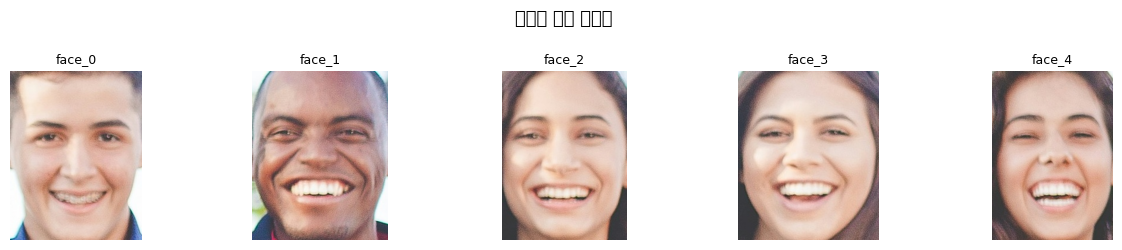

In [3]:
# 추출된 얼굴 이미지 미리보기
cols = 5
rows = (len(saved_paths) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
axes = np.array(axes).flatten()  # 항상 1D 배열로 처리

for i, path in enumerate(saved_paths):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f"face_{i}", fontsize=9)
    axes[i].axis("off")

# 남는 서브플롯 숨기기
for j in range(len(saved_paths), len(axes)):
    axes[j].axis("off")

plt.suptitle("추출된 얼굴 이미지", fontsize=13)
plt.tight_layout()
plt.show()

## 셀 3. 임베딩 추출 + FAISS 인덱스 구축

`represent()`로 각 얼굴 이미지를 벡터로 변환하고 FAISS에 저장합니다.  

```
FAISS IndexFlatL2
  index 0 → [0.12, -0.34, ...] (face_0.jpg의 임베딩)
  index 1 → [0.45,  0.23, ...] (face_1.jpg의 임베딩)
  ...

metadata.pkl
  { 0: "faces/face_0.jpg", 1: "faces/face_1.jpg", ... }
```

In [4]:
embeddings: list[np.ndarray] = []
# FAISS 인덱스 ID(정수) → 이미지 경로 매핑
metadata: dict[int, str] = {}

for i, face_path in enumerate(saved_paths):
    try:
        # represent()는 얼굴 감지 + 임베딩 추출을 한번에 수행
        # enforce_detection=False: 이미 crop된 이미지라 재감지 불필요
        result = DeepFace.represent(
            img_path=face_path,
            model_name=MODEL_NAME,
            detector_backend="skip",  # 이미 crop됐으므로 감지 단계 생략
            enforce_detection=False,
            align=False,              # extract_faces에서 이미 정렬함
        )
        # result는 리스트 — 첫 번째 결과의 임베딩 사용
        embedding = np.array(result[0]["embedding"], dtype=np.float32)
        embeddings.append(embedding)
        metadata[i] = face_path
        print(f"  face_{i} 임베딩 완료 (차원: {embedding.shape[0]})")

    except Exception as e:
        print(f"  face_{i} 임베딩 실패: {e}")

print(f"\n임베딩 완료: {len(embeddings)}개")


26-03-24 22:45:07 - 🔗 facenet512_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5 to /Users/narae/.deepface/weights/facenet512_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5
To: /Users/narae/.deepface/weights/facenet512_weights.h5
100%|██████████| 95.0M/95.0M [00:08<00:00, 11.1MB/s]


  face_0 임베딩 완료 (차원: 512)
  face_1 임베딩 완료 (차원: 512)
  face_2 임베딩 완료 (차원: 512)
  face_3 임베딩 완료 (차원: 512)
  face_4 임베딩 완료 (차원: 512)

임베딩 완료: 5개


In [5]:
metadata

{0: 'faces/face_0.jpg',
 1: 'faces/face_1.jpg',
 2: 'faces/face_2.jpg',
 3: 'faces/face_3.jpg',
 4: 'faces/face_4.jpg'}

In [6]:
embeddings

[array([-1.3566275e+00,  2.1225309e+00,  6.8574540e-02,  2.3806144e-01,
         2.0575635e-01,  8.8935733e-02, -1.3195428e+00,  1.3967038e+00,
         1.1251476e+00,  1.4248962e+00, -9.9440867e-01, -3.0629035e-02,
        -1.6698960e+00,  1.8785435e-01, -1.1952087e+00,  8.3308518e-01,
        -2.0899305e-01,  6.6035914e-01, -1.0669501e+00, -1.4050151e-01,
         4.9084783e-01,  1.0482267e+00,  2.9588792e-01, -1.3018583e-01,
         5.1762986e-01, -1.3137414e-01,  6.0579097e-01,  1.8012019e+00,
        -9.5833051e-01,  1.6889893e-01, -1.4297799e+00,  7.5145505e-02,
         1.3450941e+00,  2.5640029e-01,  5.3677434e-01,  1.3130008e+00,
         5.9481406e-01, -4.0937117e-01,  6.4540452e-01, -9.1863078e-01,
         5.1354114e-02,  1.1661310e+00,  1.7150948e+00, -2.4840659e-01,
         2.0912027e-01,  8.8463926e-01, -6.4334929e-01,  4.0881076e-01,
        -1.5817776e+00,  1.1616957e+00,  1.4662135e+00, -1.0622951e+00,
         6.8304509e-01, -7.0188916e-01, -4.0801319e-01,  8.31249

In [7]:

# --- FAISS 인덱스 구축 ---
embedding_dim = embeddings[0].shape[0]          # 모델에 따른 벡터 차원
embedding_matrix = np.vstack(embeddings)        # shape: (N, dim)

# L2 거리 기반 Flat 인덱스 (정확한 탐색, 데이터 수가 적을 때 적합)
# 데이터가 수천 장 이상이면 IndexIVFFlat이나 IndexHNSWFlat으로 교체 고려
index = faiss.IndexFlatL2(embedding_dim)
index.add(embedding_matrix)

print(f"FAISS 인덱스 구축 완료 — 저장된 벡터 수: {index.ntotal}개, 차원: {embedding_dim}")


FAISS 인덱스 구축 완료 — 저장된 벡터 수: 5개, 차원: 512


In [9]:
embeddings[0].shape

(512,)

In [8]:
embedding_matrix.shape

(5, 512)

In [10]:
# FAISS 인덱스 파일로 저장
faiss.write_index(index, str(FAISS_PATH))

# 메타데이터 pickle로 저장
with open(META_PATH, "wb") as f:
    pickle.dump(metadata, f)

print(f"저장 완료: {FAISS_PATH}, {META_PATH}")

저장 완료: faiss_index.bin, metadata.pkl


## 셀 4. FAISS로 유사 얼굴 검색

저장된 FAISS 인덱스를 불러와서, 쿼리 이미지와 가장 유사한 얼굴을 찾습니다.  
여기서는 `face_0.jpg`를 쿼리로 사용합니다 (DB에 있는 이미지를 쿼리로 쓰면 자기 자신이 1위로 나와야 정상).

In [29]:
# FAISS 인덱스 + 메타데이터 로드
loaded_index = faiss.read_index(str(FAISS_PATH))

with open(META_PATH, "rb") as f:
    loaded_metadata: dict[int, str] = pickle.load(f)

print(f"FAISS 인덱스 로드 완료 — 벡터 수: {loaded_index.ntotal}개")


def search_face(query_img_path: str, top_k: int = 3) -> list[dict]:
    """
    쿼리 이미지와 가장 유사한 얼굴을 FAISS에서 검색한다.

    Args:
        query_img_path: 검색할 얼굴 이미지 경로
        top_k: 반환할 유사 결과 수

    Returns:
        [{ "rank": int, "img_path": str, "l2_distance": float }, ...]
    """
    # 쿼리 이미지 임베딩 추출
    result = DeepFace.represent(
        img_path=query_img_path,
        model_name=MODEL_NAME,
        detector_backend="skip",
        enforce_detection=False,
        align=False,
    )
    query_vector = np.array(result[0]["embedding"], dtype=np.float32).reshape(1, -1)

    # FAISS 검색 — distances: L2 거리, indices: FAISS 인덱스 ID
    distances, indices = loaded_index.search(query_vector, top_k)

    results = []
    for rank, (dist, idx) in enumerate(zip(distances[0], indices[0])):
        results.append({
            "rank": rank + 1,
            "img_path": loaded_metadata[idx],
            "l2_distance": float(dist),
        })
    return results


# face_0.jpg를 쿼리로 검색
QUERY_IMG = saved_paths[0]
search_results = search_face(QUERY_IMG, top_k=3)

print(f"\n쿼리 이미지: {QUERY_IMG}")
print("-" * 45)
for r in search_results:
    print(f"  #{r['rank']}  {r['img_path']}  (L2 거리: {r['l2_distance']:.4f})")

FAISS 인덱스 로드 완료 — 벡터 수: 5개

쿼리 이미지: faces/face_0.jpg
---------------------------------------------
  #1  faces/face_0.jpg  (L2 거리: 0.0000)
  #2  faces/face_3.jpg  (L2 거리: 835.7750)
  #3  faces/face_2.jpg  (L2 거리: 896.1407)


In [49]:
# test.png를 불러와서 extract_faces를 하기 
face_objs = DeepFace.extract_faces(
    img_path="./images/test.png",
    detector_backend=DETECTOR_BACKEND,
    enforce_detection=True,
    align=True,
)

print(f"감지된 얼굴 수: {len(face_objs)}개")

감지된 얼굴 수: 2개


In [50]:
face_one = face_objs[0]['face']

In [51]:
# 임베딩하기 
result = DeepFace.represent(
    img_path=face_one,
    model_name=MODEL_NAME,
    detector_backend="skip",  # 이미 crop됐으므로 감지 단계 생략
    enforce_detection=False,
    align=False,              # extract_faces에서 이미 정렬함
)
embedding_one = np.array(result[0]["embedding"], dtype=np.float32)

In [52]:
loaded_index = faiss.read_index(str(FAISS_PATH))
print(loaded_index.ntotal)

5


In [53]:
with open(META_PATH, "rb") as f:
    loaded_metadata: dict[int, str] = pickle.load(f)

print(loaded_metadata)

{0: 'faces/face_0.jpg', 1: 'faces/face_1.jpg', 2: 'faces/face_2.jpg', 3: 'faces/face_3.jpg', 4: 'faces/face_4.jpg'}


In [54]:
embedding_one.shape

(512,)

In [ ]:
query_vector = embedding_one.reshape(1, -1)
query_vector.shape

(1, 512)

In [56]:
top_k = 2
distances, indices = loaded_index.search(query_vector, top_k)

In [57]:
distances

array([[ 62.136787, 554.65454 ]], dtype=float32)

In [58]:
indices

array([[2, 3]])

In [59]:
loaded_metadata[2]

'faces/face_2.jpg'

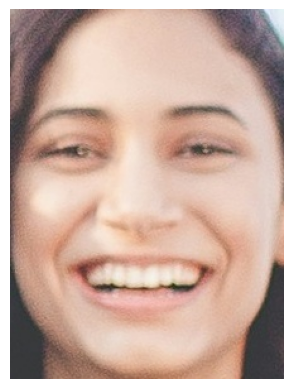

In [60]:
img = cv2.imread(loaded_metadata[2])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
results = DeepFace.represent(
    img_path="./images/test.png",
    model_name=MODEL_NAME,
    detector_backend=DETECTOR_BACKEND, 
    enforce_detection=False,
    align=True,             
)

In [75]:
# 전체 확인 코드 만들기 

## STEP0. 저장된 데이터베이스 불러오기
loaded_index = faiss.read_index(str(FAISS_PATH))
print(loaded_index.ntotal)

with open(META_PATH, "rb") as f:
    loaded_metadata: dict[int, str] = pickle.load(f)

print(loaded_metadata)

top_k = 1

## STEP1. 이미지에서 얼굴 추출하기 
results = DeepFace.represent(
    img_path="./images/test.png",
    model_name=MODEL_NAME,
    detector_backend=DETECTOR_BACKEND,  
    enforce_detection=False,
    align=True,              
)

print(f"감지된 얼굴 수: {len(face_objs)}개")

## STEP2. for 문으로 이미지 임베딩하기 
for res in results:
    print(res.keys())
    print(res["facial_area"])
    embedding = np.array(res["embedding"], dtype=np.float32)
    query_vector = embedding.reshape(1, -1)

    distances, indices = loaded_index.search(query_vector, top_k)

    print(loaded_metadata[indices[0][0]])


5
{0: 'faces/face_0.jpg', 1: 'faces/face_1.jpg', 2: 'faces/face_2.jpg', 3: 'faces/face_3.jpg', 4: 'faces/face_4.jpg'}
감지된 얼굴 수: 2개
dict_keys(['embedding', 'facial_area', 'face_confidence'])
{'x': 58, 'y': 53, 'w': 78, 'h': 105, 'left_eye': (109, 90), 'right_eye': (74, 99), 'nose': (94, 114), 'mouth_left': (118, 123), 'mouth_right': (83, 131)}
faces/face_2.jpg
dict_keys(['embedding', 'facial_area', 'face_confidence'])
{'x': 276, 'y': 78, 'w': 85, 'h': 114, 'left_eye': (333, 119), 'right_eye': (294, 128), 'nose': (315, 139), 'mouth_left': (341, 153), 'mouth_right': (301, 160)}
faces/face_1.jpg


In [ ]:
test_dict = {'x': 58, 'y': 53, 'w': 78, 'h': 105}

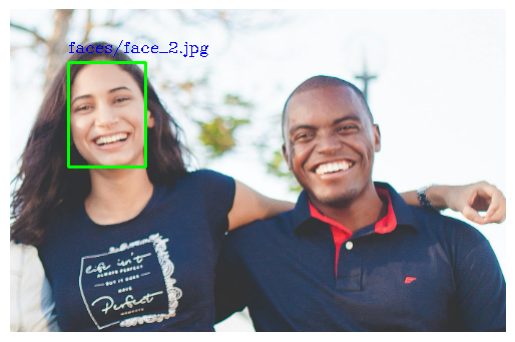

In [82]:
img = cv2.imread("./images/test.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.rectangle(img, (test_dict['x'], test_dict['y'], test_dict['w'], test_dict['h']), (0,255,0), 2)
cv2.putText(img, "faces/face_2.jpg", (test_dict['x'], test_dict['y']-10), cv2.FONT_HERSHEY_COMPLEX, 0.5, (0,0,255), 1)

plt.imshow(img)
plt.axis('off')
plt.show()

## 셀 5. 결과 시각화

쿼리 이미지와 Top-K 검색 결과를 나란히 출력합니다.  
L2 거리가 0에 가까울수록 동일한 얼굴입니다.

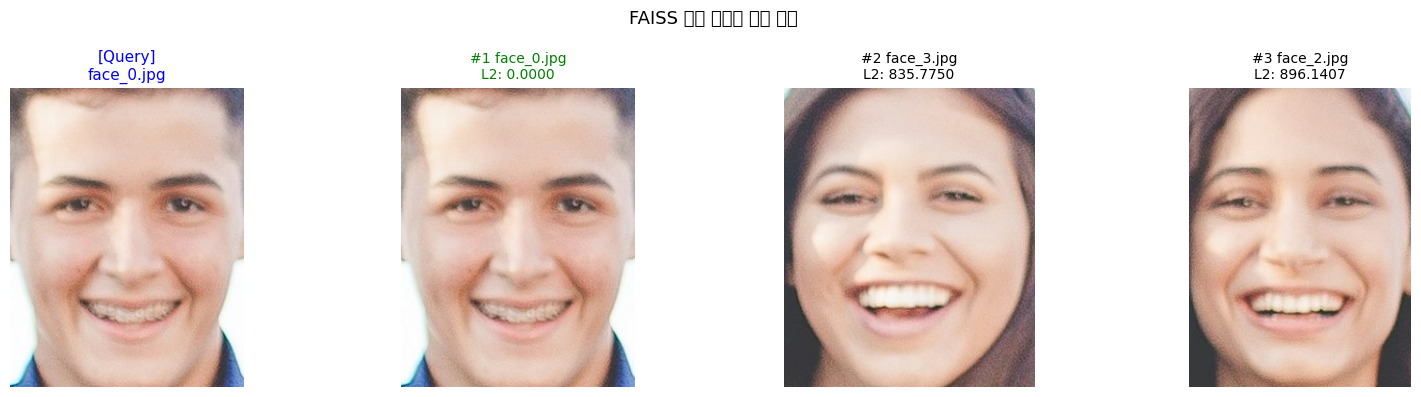

In [61]:
def load_rgb(path: str) -> np.ndarray:
    """이미지 파일을 RGB numpy array로 로드한다."""
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)


fig, axes = plt.subplots(1, len(search_results) + 1, figsize=(4 * (len(search_results) + 1), 4))

# 쿼리 이미지
axes[0].imshow(load_rgb(QUERY_IMG))
axes[0].set_title("[Query]\n" + Path(QUERY_IMG).name, fontsize=11, color="blue")
axes[0].axis("off")

# 검색 결과
for r in search_results:
    ax = axes[r["rank"]]
    ax.imshow(load_rgb(r["img_path"]))
    ax.set_title(
        f"#{r['rank']} {Path(r['img_path']).name}\nL2: {r['l2_distance']:.4f}",
        fontsize=10,
        # 동일 이미지(자기 자신)는 초록, 아니면 검정
        color="green" if r["l2_distance"] < 1e-3 else "black",
    )
    ax.axis("off")

plt.suptitle("FAISS 얼굴 유사도 검색 결과", fontsize=13)
plt.tight_layout()
plt.show()